In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath(".."))

from src.utils.rate_utils import GetRates
from src.assets.bond import Bond
from src.assets.portfolio import BondPortfolio
from src.assets.pricing import price_bond
from src.liabilities.deposit_model import DepositModel
from src.liabilities.cashflow_generator import present_value
from src.rates.hull_white import HullWhite
from src.risk.monte_carlo import MonteCarlo

In [201]:
# loading yield curves
df = pd.read_csv(
    "../data/processed/cleaned_yield_curve_fred.csv",
    index_col = 'date',
    parse_dates = True
)

# extracting latest yield curve
curve = GetRates().get_latest_curve(df)

# extracting initial short rate
r0 = GetRates().get_short_rate(curve)

# building balance sheet components
### -- ASSETS --
bonds = [
    Bond(face_value=1000, coupon_rate=0.02, maturity=3),
    Bond(face_value=1000, coupon_rate=0.03, maturity=5),
    Bond(face_value=1000, coupon_rate=0.04, maturity=10)
]

bond_portfolio = BondPortfolio(bonds)

### -- LIABILITIES --
deposit_model = DepositModel(initial_amount=11700, decay_rate=0.965)

# initializing HW model
theta = float(np.mean(list(curve.values())))

HW_model = HullWhite(
    a = 0.1,
    sigma = 0.01,
    initial_rate = r0,
    theta = theta
)

# simulating interest rate paths
ir_paths = HW_model.simulate_paths(
    n_paths = 1000,
    n_steps = 60,
    dt = 1.0
)

print(f"Interest Rate Paths Shape (n_paths, n_steps): {ir_paths.shape}")

Interest Rate Paths Shape (n_paths, n_steps): (1000, 60)


In [202]:
# running monte carlo simulation
alm_mc = MonteCarlo(
    portfolio = bond_portfolio,
    deposit_model = deposit_model,
    pricing_function = price_bond,
    liability_pv_function = present_value
)

results = alm_mc.run_simulation(
    rate_paths = ir_paths,
    dt = 1.0
)

df_results = pd.DataFrame(results)
df_results

,assets,liabilities,equity,funding_ratio
0,2875.144082,2854.715094,20.428989,1.007156
1,2833.791783,2817.656677,16.135106,1.005726
2,2560.670599,2571.861175,-11.190576,0.995649
3,3022.292071,2986.255728,36.036343,1.012067
4,3032.467745,2995.333340,37.134404,1.012397
...,...,...,...,...
995,2953.826375,2925.115276,28.711100,1.009815
996,2941.544337,2914.135675,27.408662,1.009405
997,3145.221869,3095.759542,49.462327,1.015977
998,2888.710145,2866.863643,21.846502,1.007620


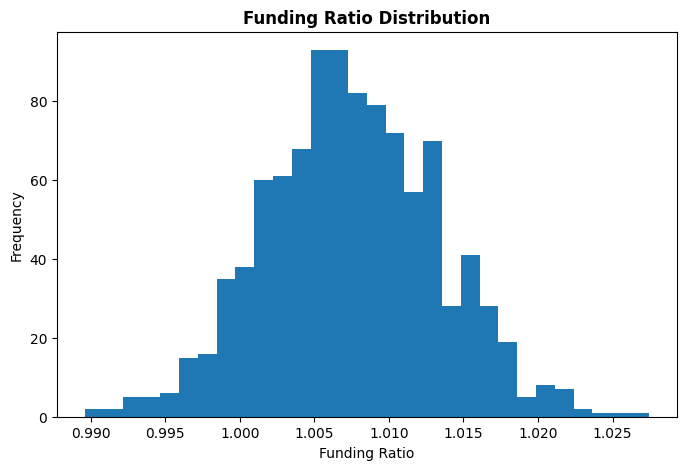

In [203]:
# funding ration distribution
plt.figure(figsize=(8, 5))
plt.hist(df_results['funding_ratio'], bins = 30)

plt.title('Funding Ratio Distribution', fontweight = 'bold')
plt.xlabel('Funding Ratio')
plt.ylabel('Frequency')
plt.show()

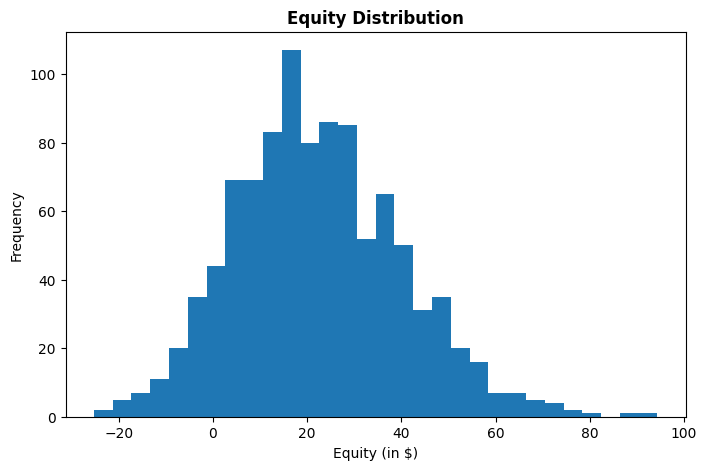

In [204]:
# equity distribution
plt.figure(figsize=(8, 5))
plt.hist(df_results['equity'], bins = 30)

plt.title('Equity Distribution', fontweight = 'bold')
plt.xlabel('Equity (in $)')
plt.ylabel('Frequency')
plt.show()

In [205]:
# probability of underfunding
prob_underfunding = float((df_results['funding_ratio'] < 1).mean())
print(f"Probability of Underfunding: {prob_underfunding:.2f}")

Probability of Underfunding: 0.10


In [ ]:
# Value-at-Risk - the maximum loss expected with 95% confidence
var_95 = np.percentile(df_results['equity'], 5)
print(f"Equity VaR (95%): {var_95:.2f}")

# worst-case scenario respect to the lowest 10 equities
df_results.nsmallest(10, 'equity')

Equity VaR (95%): -4.18


,assets,liabilities,equity,funding_ratio
198,2412.175250,2437.456844,-25.281594,0.989628
911,2433.467203,2456.761883,-23.294681,0.990518
921,2460.288212,2481.064009,-20.775798,0.991626
154,2460.879338,2481.599419,-20.720081,0.991651
354,2473.712594,2493.220953,-19.508359,0.992175
473,2475.109448,2494.485669,-19.376221,0.992232
25,2481.833446,2500.572924,-18.739478,0.992506
805,2498.790598,2515.919318,-17.128721,0.993192
446,2501.360440,2518.244432,-16.883992,0.993295
199,2510.566129,2526.572115,-16.005986,0.993665


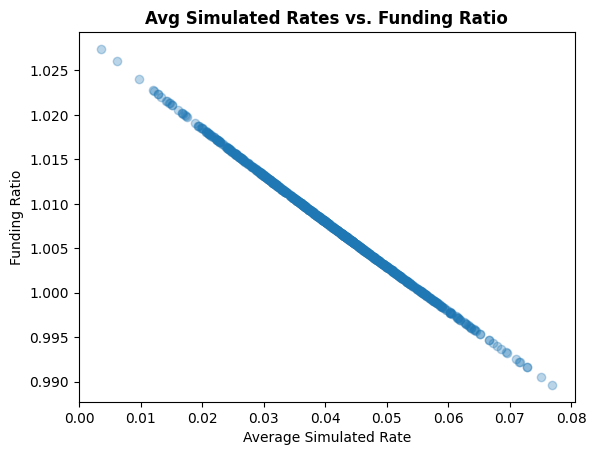

In [218]:
# rates vs. funding ratio
avg_rates_per_step = ir_paths.mean(axis = 1)
plt.scatter(avg_rates_per_step, df_results['funding_ratio'], alpha = 0.3)
plt.xlabel('Average Simulated Rate')
plt.ylabel('Funding Ratio')
plt.title('Avg Simulated Rates vs. Funding Ratio', fontweight = 'bold')
plt.show()